# `CPPStructurePlot.plot_combined`

Show the **3D structure and the CPP feature map side by side**, reproducing the deployed cleavage app's signature layout: the **left** panel is the interactive `py3Dmol` cartoon painted with per-residue CPP feature impact, the **right** panel is the `CPPPlot.feature_map` of the same `df_feat`. Both read the same per-residue impact. Returns a `CombinedView` that renders inline and exports the pair with `write_html`.

This is a `pro` feature (needs `biopython` + `py3Dmol`).

In [1]:
import pandas as pd
import aaanalysis as aa
import aaanalysis.utils as ut

aa.options["verbose"] = False

## A `df_feat` and a real structure

As in `map_structure`, we use the human lysozyme C AlphaFold model (`uniprot='P61626'`) and a `df_feat` with a signed `feat_impact` (from `CPP.run` + `ShapModel` in practice).

In [2]:
df_cat = aa.load_scales(name='scales_cat').head(5).reset_index(drop=True)
splits = ['Segment(1,2)', 'Segment(2,2)', 'Segment(1,1)', 'Pattern(C,1)', 'Segment(1,4)']
parts = ['TMD', 'TMD', 'JMD_N', 'TMD', 'JMD_C']
df_feat = pd.DataFrame({
    ut.COL_FEATURE: [f"{parts[i]}-{splits[i]}-{r[ut.COL_SCALE_ID]}" for i, r in df_cat.iterrows()],
    'category': df_cat[ut.COL_CAT], 'subcategory': df_cat[ut.COL_SUBCAT],
    'scale_name': df_cat[ut.COL_SCALE_NAME],
    'abs_auc': [0.2, 0.15, 0.3, 0.1, 0.25], 'abs_mean_dif': [0.3, 0.2, 0.5, 0.4, 0.35],
    'mean_dif': [0.3, -0.2, 0.5, -0.4, 0.25], 'std_test': 0.1, 'std_ref': 0.1,
    'feat_impact': [0.8, -0.5, 1.2, -0.3, 0.6]})
aa.display_df(df_feat, n_rows=10, show_shape=True)

DataFrame shape: (5, 10)


,feature,category,subcategory,scale_name,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,feat_impact
1,"TMD-Segment(1,2)-LINS030110",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.200000,0.300000,0.300000,0.100000,0.100000,0.800000
2,"TMD-Segment(2,2)-LINS030113",ASA/Volume,Accessible surface area (ASA),ASA (folded coil/turn),0.150000,0.200000,-0.200000,0.100000,0.100000,-0.500000
3,"JMD_N-Segment(1,1)-JANJ780101",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.300000,0.500000,0.500000,0.100000,0.100000,1.200000
4,"TMD-Pattern(C,1)-JANJ780103",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.100000,0.400000,-0.400000,0.100000,0.100000,-0.300000
5,"JMD_C-Segment(1,4)-LINS030104",ASA/Volume,Accessible surface area (ASA),ASA (folded protein),0.250000,0.350000,0.250000,0.100000,0.100000,0.600000


## The combined view

`mode` (`impact`/`plddt`) and `focus` (`whole`/`fade`/`zoom`) style the structure; `normalize_by_span` controls the per-residue aggregation (see `map_structure`).


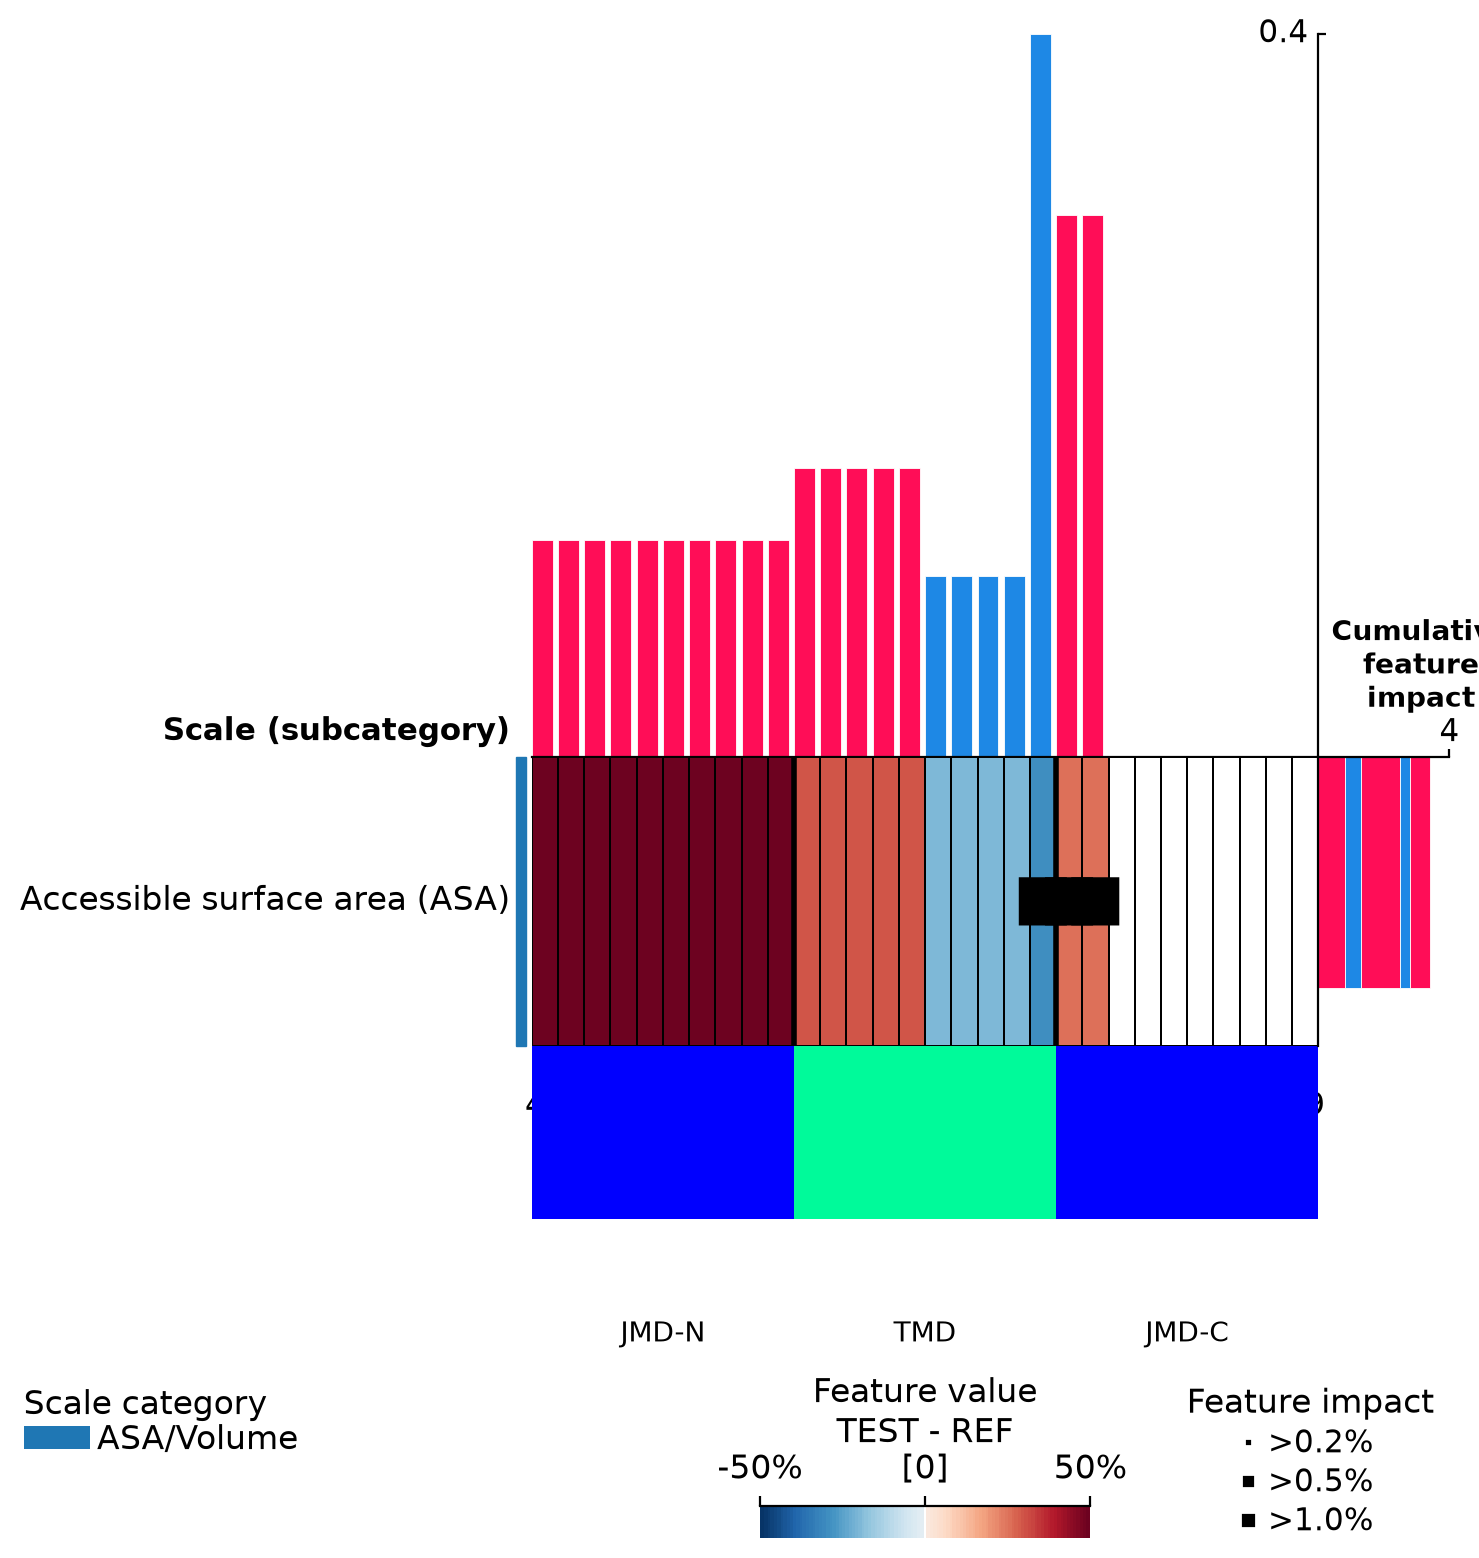

In [3]:
cpps_plot = aa.CPPStructurePlot(jmd_n_len=10, jmd_c_len=10, verbose=False)
view = cpps_plot.plot_combined(df_feat=df_feat, uniprot='P61626', col_imp='feat_impact',
                         tmd_len=10, start=40, mode='impact', focus='fade')
view

## Styling and feature-map options

`size_by_impact` scales each impact residue's stick by `|impact|`; `normalize_by_span` switches the per-residue aggregation (app-fidelity vs the span-normalized sum used by `CPPPlot.profile`); `feature_map_dpi` sets the embedded image resolution. (A local `.pdb` file works in place of `uniprot=` via `pdb=`.)


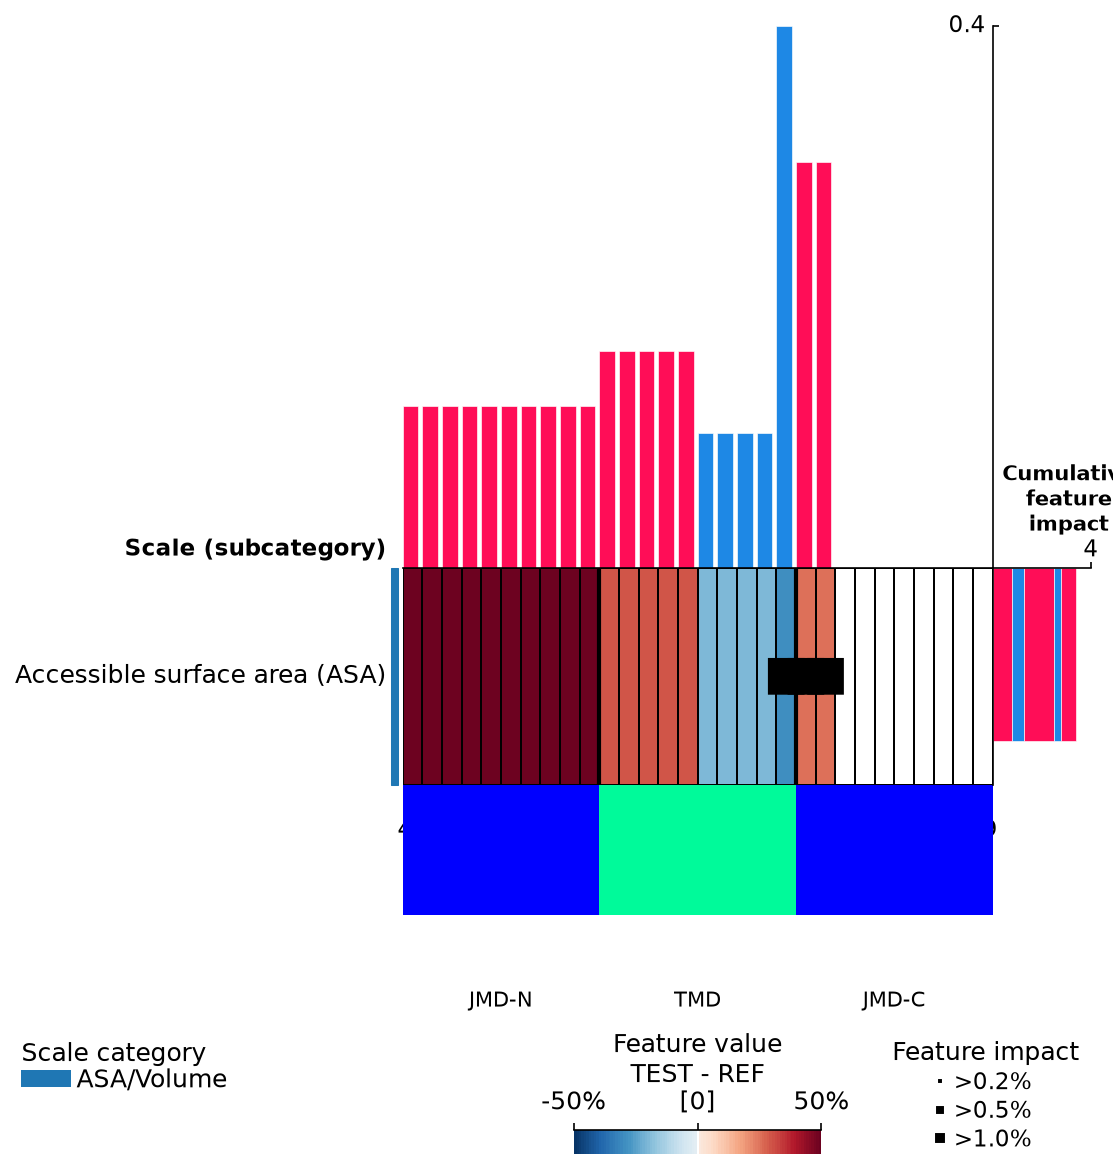

In [4]:
cpps_plot.plot_combined(df_feat=df_feat, uniprot='P61626', col_imp='feat_impact', tmd_len=10, start=40,
                  size_by_impact=False, normalize_by_span=True, feature_map_dpi=150)

Export the side-by-side structure + feature map as one self-contained page:

In [5]:
import tempfile, os
tmp = tempfile.mkdtemp()
view.write_html(os.path.join(tmp, 'combined.html'))   # interactive side-by-side page
view.savefig(os.path.join(tmp, 'combined.pdf'))       # static feature-map panel (PNG/PDF) for papers
print('wrote combined.html + combined.pdf to', tmp)

wrote combined.html + combined.pdf to /var/folders/sv/65tlch_10198qgmpwcp6408r0000gn/T/tmpflj2vyuu


For a live, re-predicting explorer (slider-driven), use `CPPStructurePlot.interactive`.


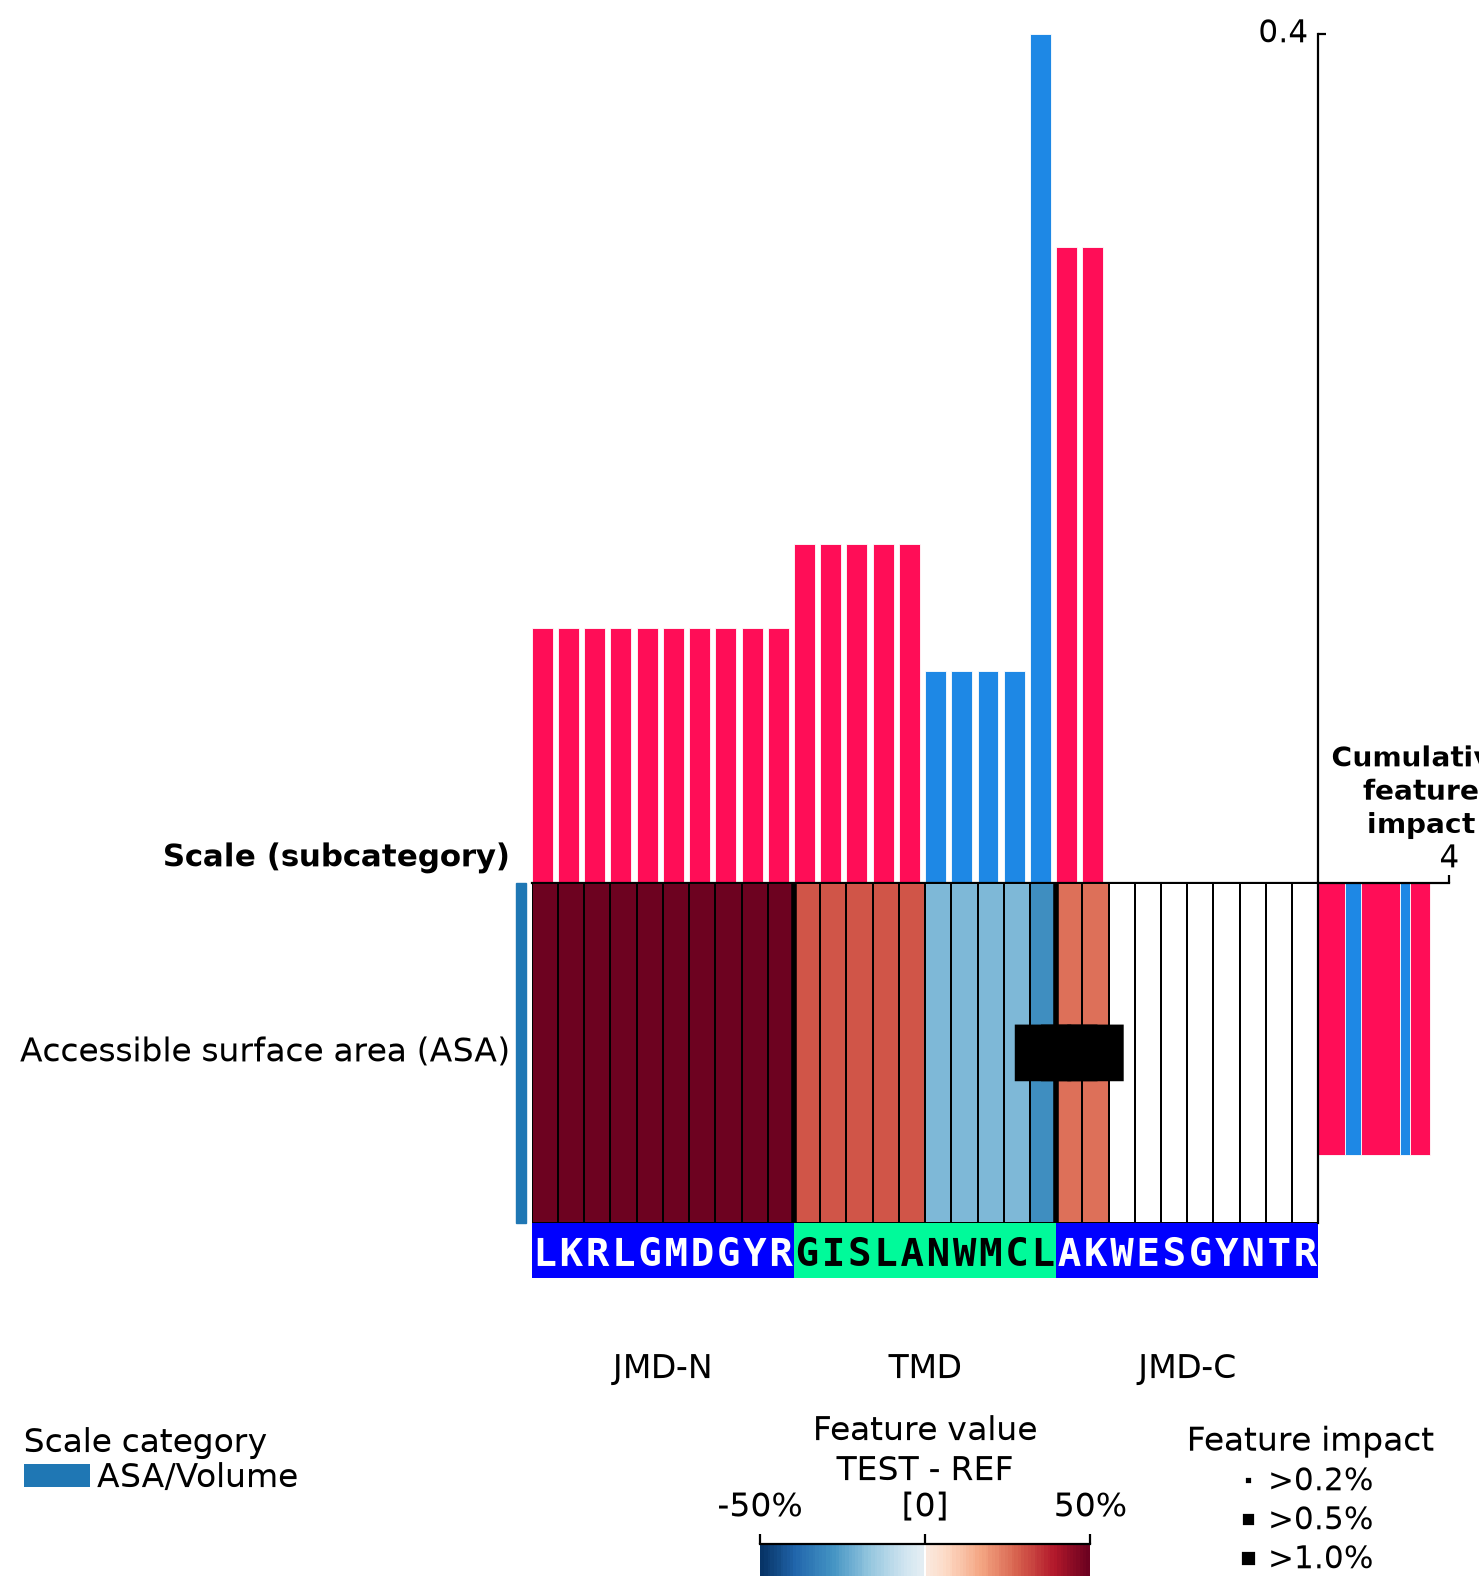

In [6]:
# Further parameters. Select a ``chain``, pick the value column (``col_val``),
# enable the SHAP overlay (``shap_plot``), frame the camera (``focus_region``),
# pass the part sequences (``sequence`` / ``tmd_seq`` / ``jmd_n_seq`` / ``jmd_c_seq``),
# and forward feature-map options (``feature_map_kws``).
seq = ("MKALIVLGLVLLSVTVQGKVFERCELARTLKRLGMDGYRGISLANWMCLAKWESGYNTRATNYNAGDRSTDYGIFQINS"
       "RYWCNDGKTPGAVNACHLSCSALLQDNIADAVACAKRVVRDPQGIRAWVAWRNRCQNRDVRQYVQGCGV")
cpps_plot.plot_combined(df_feat=df_feat, uniprot="P61626", col_imp="feat_impact", col_val="mean_dif",
                        tmd_len=10, start=40, chain="A", shap_plot=True, focus_region=(40, 49),
                        sequence=seq, tmd_seq=seq[39:49], jmd_n_seq=seq[29:39], jmd_c_seq=seq[49:59],
                        feature_map_kws={})
# ``pdb=<local .pdb/.cif file>`` is the offline alternative to ``uniprot=``.